# U.S. Oil and Gas Production Analysis


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbresult


## Natural Gas Production


In [2]:
import pandas as pd

df = pd.read_csv("data/U.S._crude_oil_production.csv.xls")
df.head()


,Month,U.S. Crude Oil,Alabama,Alaska,Arkansas,Arizona,California,Colorado,Federal Offshore Gulf of Mexico Crude Oil,Federal Offshore Pacific Crude Oil,...,Ohio,Oklahoma,Pennsylvania,South Dakota,Wyoming,West Virginia,Virginia,Utah,Texas,Tennessee
0,2008-06-01,5138,21,655,17,0,583,82,1326,67,...,14,186,8,5,144,6,0,60,1097,1
1,2008-07-01,5177,21,640,17,0,586,81,1372,61,...,14,184,8,5,145,5,0,61,1111,1
2,2008-08-01,5003,21,544,17,0,588,82,1272,70,...,14,188,8,5,145,6,0,62,1110,1
3,2008-09-01,3974,21,681,16,0,587,88,242,67,...,14,186,8,5,144,6,0,63,1055,1
4,2008-10-01,4738,21,716,17,0,586,86,803,66,...,14,185,8,5,145,6,0,64,1125,1


In [3]:
df.shape


(121, 36)

In [4]:
df.columns



Index(['Month', 'U.S. Crude Oil ', 'Alabama', 'Alaska', 'Arkansas', 'Arizona',
       'California', 'Colorado', 'Federal Offshore Gulf of Mexico Crude Oil',
       'Federal Offshore Pacific Crude Oil', 'Florida', 'Idaho', 'Illinois',
       'Indiana', 'Kansas', 'Kentucky', 'Louisiana', 'Michigan', 'Mississippi',
       'Missouri', 'Nebraska', 'Montana', 'Nevada', 'New Mexico', 'New York',
       'North Dakota', 'Ohio', 'Oklahoma', 'Pennsylvania', 'South Dakota',
       'Wyoming', 'West Virginia', 'Virginia', 'Utah', 'Texas', 'Tennessee'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 36 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Month                                      121 non-null    object
 1   U.S. Crude Oil                             121 non-null    int64 
 2   Alabama                                    121 non-null    int64 
 3   Alaska                                     121 non-null    int64 
 4   Arkansas                                   121 non-null    int64 
 5   Arizona                                    121 non-null    int64 
 6   California                                 121 non-null    int64 
 7   Colorado                                   121 non-null    int64 
 8   Federal Offshore Gulf of Mexico Crude Oil  121 non-null    int64 
 9   Federal Offshore Pacific Crude Oil         121 non-null    int64 
 10  Florida                               

In [14]:
df["Month"] = pd.to_datetime(df["Month"])

In [15]:
df["Month"].dtype


dtype('<M8[ns]')

In [16]:
df.head()


,Month,U.S. Crude Oil,Alabama,Alaska,Arkansas,Arizona,California,Colorado,Federal Offshore Gulf of Mexico Crude Oil,Federal Offshore Pacific Crude Oil,...,Ohio,Oklahoma,Pennsylvania,South Dakota,Wyoming,West Virginia,Virginia,Utah,Texas,Tennessee
0,2008-06-01,5138,21,655,17,0,583,82,1326,67,...,14,186,8,5,144,6,0,60,1097,1
1,2008-07-01,5177,21,640,17,0,586,81,1372,61,...,14,184,8,5,145,5,0,61,1111,1
2,2008-08-01,5003,21,544,17,0,588,82,1272,70,...,14,188,8,5,145,6,0,62,1110,1
3,2008-09-01,3974,21,681,16,0,587,88,242,67,...,14,186,8,5,144,6,0,63,1055,1
4,2008-10-01,4738,21,716,17,0,586,86,803,66,...,14,185,8,5,145,6,0,64,1125,1


In [17]:
df["Year"] = df["Month"].dt.year
df[["Month", "Year"]].head()


,Month,Year
0,2008-06-01,2008
1,2008-07-01,2008
2,2008-08-01,2008
3,2008-09-01,2008
4,2008-10-01,2008


In [19]:
yearly_gas_df = (df.groupby("Year").sum(numeric_only=True))
yearly_gas_df.head()


,U.S. Crude Oil,Alabama,Alaska,Arkansas,Arizona,California,Colorado,Federal Offshore Gulf of Mexico Crude Oil,Federal Offshore Pacific Crude Oil,Florida,...,Ohio,Oklahoma,Pennsylvania,South Dakota,Wyoming,West Virginia,Virginia,Utah,Texas,Tennessee
Year,,,,,,,,,,,,,,,,,,,,,
2008,34211,149,4666,118,0,4095,589,7302,465,37,...,98,1286,56,35,1013,39,0,438,7773,7
2009,64180,236,7749,189,0,6815,998,18727,734,24,...,156,2144,96,55,1695,48,0,757,13132,12
2010,65741,234,7199,189,0,6588,1086,18640,713,56,...,156,2239,108,53,1771,59,0,809,14026,12
2011,67829,275,6742,195,0,6449,1295,15805,652,67,...,156,2534,114,53,1795,72,0,864,17393,12
2012,78007,312,6310,214,0,6465,1626,15189,580,71,...,168,3095,144,60,1900,85,0,991,23742,12


In [20]:
nbresult.ChallengeResult(
    "index_year",
    yearly_gas_df.index.name == "Year" or yearly_gas_df.index.dtype == "int64"
)


In [21]:
nbresult.ChallengeResult(
    "yearly_gas_shape",
    yearly_gas_df.shape[0] > 0 and yearly_gas_df.shape[1] > 0
)


In [22]:
nbresult.ChallengeResult(
    "full_gas",
    yearly_gas_df.select_dtypes("number").sum().sum() > 0
)


In [24]:
df["Year"] = df["Month"].dt.year
df["Month_num"] = df["Month"].dt.month


In [25]:
months_per_year = (
    df.groupby("Year")["Month_num"]
      .nunique()
)

months_per_year.head()


Year
2008     7
2009    12
2010    12
2011    12
2012    12
Name: Month_num, dtype: int64

In [26]:
full_years = months_per_year[months_per_year == 12].index

filtered_yearly_gas_df = yearly_gas_df.loc[full_years]


In [27]:
import nbresult

nbresult.ChallengeResult(
    "filtered_gas",
    filtered_yearly_gas_df.shape[0] > 0
)


In [29]:
filtered_yearly_gas_df.columns


Index(['U.S. Crude Oil ', 'Alabama', 'Alaska', 'Arkansas', 'Arizona',
       'California', 'Colorado', 'Federal Offshore Gulf of Mexico Crude Oil',
       'Federal Offshore Pacific Crude Oil', 'Florida', 'Idaho', 'Illinois',
       'Indiana', 'Kansas', 'Kentucky', 'Louisiana', 'Michigan', 'Mississippi',
       'Missouri', 'Nebraska', 'Montana', 'Nevada', 'New Mexico', 'New York',
       'North Dakota', 'Ohio', 'Oklahoma', 'Pennsylvania', 'South Dakota',
       'Wyoming', 'West Virginia', 'Virginia', 'Utah', 'Texas', 'Tennessee'],
      dtype='object')

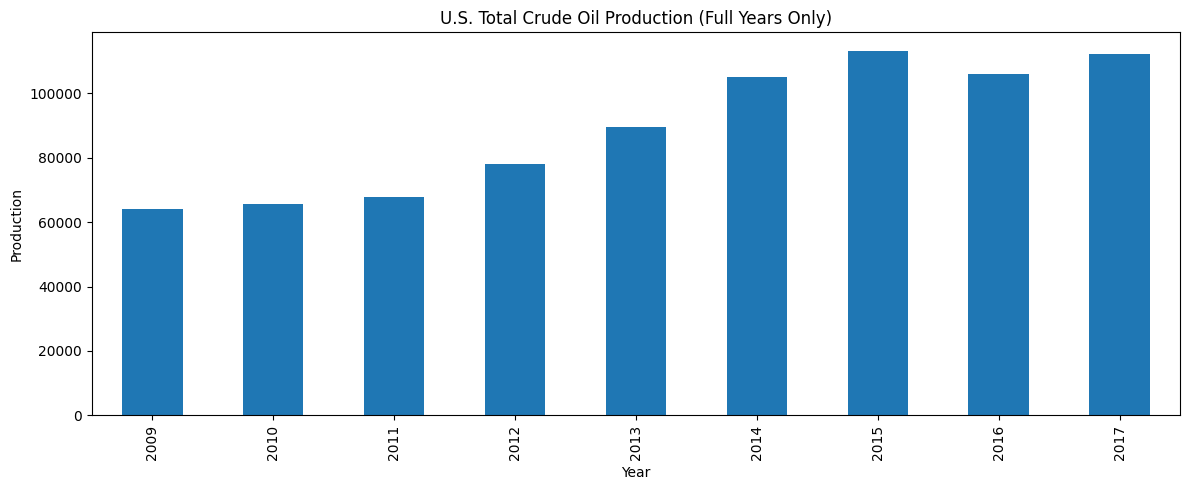

In [30]:
filtered_yearly_gas_df["U.S. Crude Oil "].plot(
    kind="bar",
    figsize=(12, 5),
    title="U.S. Total Crude Oil Production (Full Years Only)"
)

plt.xlabel("Year")
plt.ylabel("Production")
plt.tight_layout()
plt.show()


## Crude Oil Production


In [33]:
oil_df = pd.read_csv("data/U.S._crude_oil_production.csv.xls", parse_dates=["Month"])
oil_df.head()

,Month,U.S. Crude Oil,Alabama,Alaska,Arkansas,Arizona,California,Colorado,Federal Offshore Gulf of Mexico Crude Oil,Federal Offshore Pacific Crude Oil,...,Ohio,Oklahoma,Pennsylvania,South Dakota,Wyoming,West Virginia,Virginia,Utah,Texas,Tennessee
0,2008-06-01,5138,21,655,17,0,583,82,1326,67,...,14,186,8,5,144,6,0,60,1097,1
1,2008-07-01,5177,21,640,17,0,586,81,1372,61,...,14,184,8,5,145,5,0,61,1111,1
2,2008-08-01,5003,21,544,17,0,588,82,1272,70,...,14,188,8,5,145,6,0,62,1110,1
3,2008-09-01,3974,21,681,16,0,587,88,242,67,...,14,186,8,5,144,6,0,63,1055,1
4,2008-10-01,4738,21,716,17,0,586,86,803,66,...,14,185,8,5,145,6,0,64,1125,1


In [34]:
yearly_oil_df = (
    oil_df
    .assign(Year=oil_df["Month"].dt.year)
    .groupby("Year")
    .sum(numeric_only=True)
)

yearly_oil_df.head()


,U.S. Crude Oil,Alabama,Alaska,Arkansas,Arizona,California,Colorado,Federal Offshore Gulf of Mexico Crude Oil,Federal Offshore Pacific Crude Oil,Florida,...,Ohio,Oklahoma,Pennsylvania,South Dakota,Wyoming,West Virginia,Virginia,Utah,Texas,Tennessee
Year,,,,,,,,,,,,,,,,,,,,,
2008,34211,149,4666,118,0,4095,589,7302,465,37,...,98,1286,56,35,1013,39,0,438,7773,7
2009,64180,236,7749,189,0,6815,998,18727,734,24,...,156,2144,96,55,1695,48,0,757,13132,12
2010,65741,234,7199,189,0,6588,1086,18640,713,56,...,156,2239,108,53,1771,59,0,809,14026,12
2011,67829,275,6742,195,0,6449,1295,15805,652,67,...,156,2534,114,53,1795,72,0,864,17393,12
2012,78007,312,6310,214,0,6465,1626,15189,580,71,...,168,3095,144,60,1900,85,0,991,23742,12


In [35]:
yearly_oil_df.columns = yearly_oil_df.columns.str.strip()


In [36]:
yearly_oil_df.columns


Index(['U.S. Crude Oil', 'Alabama', 'Alaska', 'Arkansas', 'Arizona',
       'California', 'Colorado', 'Federal Offshore Gulf of Mexico Crude Oil',
       'Federal Offshore Pacific Crude Oil', 'Florida', 'Idaho', 'Illinois',
       'Indiana', 'Kansas', 'Kentucky', 'Louisiana', 'Michigan', 'Mississippi',
       'Missouri', 'Nebraska', 'Montana', 'Nevada', 'New Mexico', 'New York',
       'North Dakota', 'Ohio', 'Oklahoma', 'Pennsylvania', 'South Dakota',
       'Wyoming', 'West Virginia', 'Virginia', 'Utah', 'Texas', 'Tennessee'],
      dtype='object')

In [37]:
months_per_year = oil_df.groupby(oil_df["Month"].dt.year)["Month"].count()

full_years = months_per_year[months_per_year == 12].index

filtered_yearly_oil_df = yearly_oil_df.loc[full_years]

filtered_yearly_oil_df.head()


,U.S. Crude Oil,Alabama,Alaska,Arkansas,Arizona,California,Colorado,Federal Offshore Gulf of Mexico Crude Oil,Federal Offshore Pacific Crude Oil,Florida,...,Ohio,Oklahoma,Pennsylvania,South Dakota,Wyoming,West Virginia,Virginia,Utah,Texas,Tennessee
Month,,,,,,,,,,,,,,,,,,,,,
2009,64180,236,7749,189,0,6815,998,18727,734,24,...,156,2144,96,55,1695,48,0,757,13132,12
2010,65741,234,7199,189,0,6588,1086,18640,713,56,...,156,2239,108,53,1771,59,0,809,14026,12
2011,67829,275,6742,195,0,6449,1295,15805,652,67,...,156,2534,114,53,1795,72,0,864,17393,12
2012,78007,312,6310,214,0,6465,1626,15189,580,71,...,168,3095,144,60,1900,85,0,991,23742,12
2013,89585,342,6182,218,0,6540,2175,15068,610,72,...,264,3786,174,60,2088,237,0,1152,30475,12


In [38]:
nbresult.ChallengeResult(
    "oil_year_shape",
    filtered_yearly_oil_df.shape[0] > 0 and filtered_yearly_oil_df.shape[1] > 0
)

nbresult.ChallengeResult(
    "oil_columns_clean",
    all(col == col.strip() for col in filtered_yearly_oil_df.columns)
)

nbresult.ChallengeResult(
    "oil_full",
    filtered_yearly_oil_df.select_dtypes("number").sum().sum() > 0
)


In [40]:
total_gas = filtered_yearly_gas_df.sum(axis=1).to_frame(name="total_gas")
total_gas.head()


,total_gas
Year,
2009,128350
2010,131476
2011,135655
2012,156016
2013,179176


In [44]:
filtered_yearly_oil_df.columns = filtered_yearly_oil_df.columns.str.strip()
total_oil = filtered_yearly_oil_df[["U.S. Crude Oil"]].rename(columns={"U.S. Crude Oil": "total_oil"})
total_oil.head()


,total_oil
Month,
2009,64180
2010,65741
2011,67829
2012,78007
2013,89585


In [45]:
merged_df = pd.concat([total_gas, total_oil], axis=1)
merged_df.head()


,total_gas,total_oil
2009,128350,64180
2010,131476,65741
2011,135655,67829
2012,156016,78007
2013,179176,89585


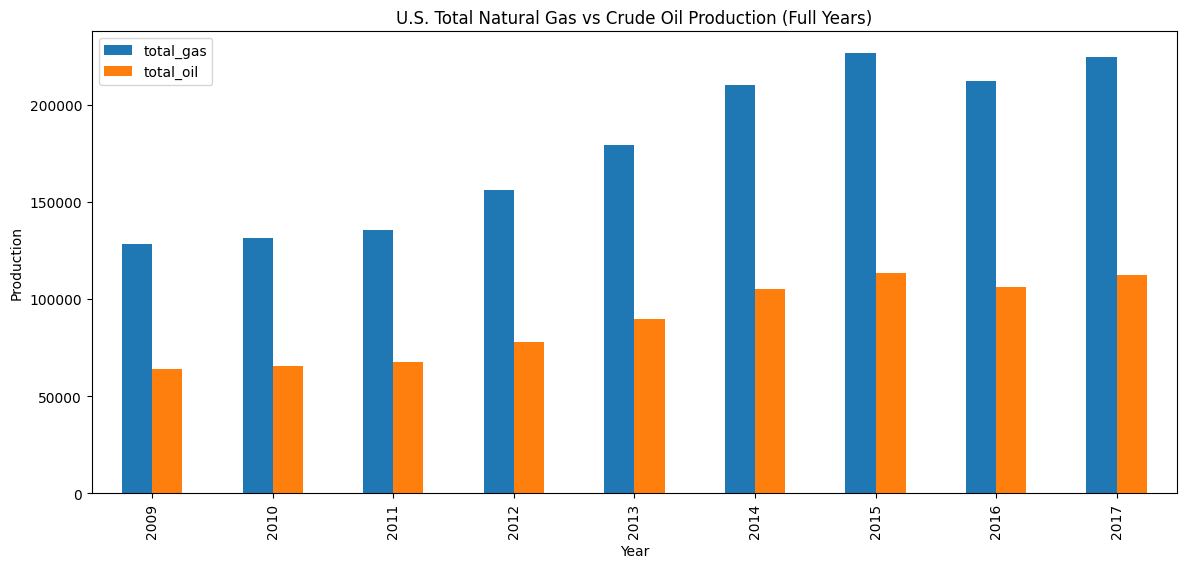

In [46]:
merged_df.plot(
    kind="bar",
    figsize=(14, 6),
    title="U.S. Total Natural Gas vs Crude Oil Production (Full Years)"
)

plt.xlabel("Year")
plt.ylabel("Production")
plt.show()
